# Generic Signal Research Viewer

Use this notebook to inspect signal-research outputs under `research/output/<run_tag>/` for workflows that produce repo diagnostics, Alphalens diagnostics, or both.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def resolve_output_root() -> Path:
    candidates = [Path('research/output'), Path('../research/output')]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError('Could not find research/output from current directory.')

def classify_run(path: Path) -> dict:
    files = {
        'repo_summary': path / 'repo_summary.csv',
        'repo_by_date': path / 'repo_by_date.csv',
        'summary': path / 'summary.csv',
        'by_date': path / 'by_date.csv',
        'alphalens_summary': path / 'alphalens_summary.csv',
        'alphalens_ic_by_date': path / 'alphalens_ic_by_date.csv',
        'alphalens_turnover': path / 'alphalens_turnover_autocorr.csv',
        'params': path / 'params.json',
        'manifest': path / 'manifest.json',
    }
    exists = {k: v.exists() for k, v in files.items()}
    # Generic signal-run detection: has repo summary or alphalens summary or classic summary/by_date pair.
    is_run = bool(exists['repo_summary'] or exists['alphalens_summary'] or exists['summary'])
    return {'is_run': is_run, 'files': files, 'exists': exists}

OUT_ROOT = resolve_output_root()
rows = []
for p in sorted([d for d in OUT_ROOT.iterdir() if d.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True):
    info = classify_run(p)
    if not info['is_run']:
        continue
    rows.append({
        'run_tag': p.name,
        'modified_time': pd.to_datetime(p.stat().st_mtime, unit='s').strftime('%Y-%m-%d %H:%M:%S'),
        'has_repo_summary': info['exists']['repo_summary'],
        'has_alphalens_summary': info['exists']['alphalens_summary'],
        'has_summary': info['exists']['summary'],
        'path': str(p),
    })

runs_df = pd.DataFrame(rows)
assert not runs_df.empty, f'No compatible signal research runs found under {OUT_ROOT.resolve()}'
runs_df.head(10)

,run_tag,modified_time,has_repo_summary,has_alphalens_summary,has_summary,path
0,sp500_price_volume_alpha_sweep_20260426,2026-04-26 20:45:35,False,False,True,../research/output/sp500_price_volume_alpha_sw...
1,sp500_price_volume_alpha_smoke_20260426,2026-04-26 20:44:27,False,False,True,../research/output/sp500_price_volume_alpha_sm...


In [3]:
# Optional explicit run selection. If None, latest run is used.
RUN_TAG = None

selected = RUN_TAG if RUN_TAG else str(runs_df.iloc[0]['run_tag'])
RUN_DIR = OUT_ROOT / selected
info = classify_run(RUN_DIR)

print('Using run:', selected)
print('Run dir:', RUN_DIR.resolve())
print('Available artifacts:')
for k, ok in info['exists'].items():
    if ok:
        print(' -', k)

Using run: sp500_price_volume_alpha_sweep_20260426
Run dir: /home/rockebull/proj/TradingAgents/research/output/sp500_price_volume_alpha_sweep_20260426
Available artifacts:
 - summary
 - params


In [4]:
repo_summary = pd.read_csv(info['files']['repo_summary']) if info['exists']['repo_summary'] else pd.DataFrame()
repo_by_date = pd.read_csv(info['files']['repo_by_date'], parse_dates=['date']) if info['exists']['repo_by_date'] else pd.DataFrame()
summary = pd.read_csv(info['files']['summary']) if info['exists']['summary'] else pd.DataFrame()
by_date = pd.read_csv(info['files']['by_date'], parse_dates=['date']) if info['exists']['by_date'] else pd.DataFrame()
alphalens_summary = pd.read_csv(info['files']['alphalens_summary']) if info['exists']['alphalens_summary'] else pd.DataFrame()
alphalens_ic = pd.read_csv(info['files']['alphalens_ic_by_date']) if info['exists']['alphalens_ic_by_date'] else pd.DataFrame()
alphalens_turnover = pd.read_csv(info['files']['alphalens_turnover']) if info['exists']['alphalens_turnover'] else pd.DataFrame()
params = json.loads(info['files']['params'].read_text(encoding='utf-8')) if info['exists']['params'] else {}
manifest = json.loads(info['files']['manifest'].read_text(encoding='utf-8')) if info['exists']['manifest'] else {}

if not repo_summary.empty:
    display(repo_summary)
elif not summary.empty:
    display(summary)
else:
    print('No summary CSV found')

,signal,eval_dates,avg_nonzero_frac,ic_mean_1d,ic_ir_1d,spread_1d,spread_hit_1d,n_1d,ic_mean_5d,ic_ir_5d,spread_5d,spread_hit_5d,n_5d,ic_mean_20d,ic_ir_20d,spread_20d,spread_hit_20d,n_20d,rank_score
0,mom_12m_skip_1m,217,0.916675,0.004773,0.020527,-0.000561,0.515000,200,0.026551,0.129288,0.002907,0.560000,200,0.035490,0.197891,0.009402,0.629442,197,3.772414
1,vol_confirmed_mom_1m,217,0.444925,0.013639,0.114166,0.000685,0.564815,216,0.009827,0.086484,0.001794,0.564815,216,0.007618,0.070243,0.002515,0.591549,213,0.878462
2,range_breakout_3m,217,0.991910,0.010203,0.100385,0.000899,0.555556,216,0.011429,0.107054,0.001533,0.537037,216,0.001375,0.013209,0.000246,0.511737,213,0.151650
3,high_volume_reversal_1w,217,0.444623,-0.006059,-0.054586,-0.000312,0.416667,216,0.000004,0.000036,-0.000016,0.513889,216,-0.001103,-0.010838,0.000533,0.497653,213,-0.107314
4,flat_vol_breakout,217,0.004278,-0.000527,-0.009749,-0.000501,0.333333,42,-0.011592,-0.202701,0.000049,0.476190,42,-0.002675,-0.059417,0.002098,0.547619,42,-0.198851
5,vol_adj_mom_3m,217,0.991864,0.005503,0.027358,-0.000131,0.541667,216,0.000530,0.002947,-0.000291,0.495370,216,-0.003982,-0.024257,-0.000090,0.539906,213,-0.359182
6,low_vol_mom_3m,217,0.991938,0.004437,0.020656,-0.000174,0.550926,216,-0.000809,-0.004239,0.000459,0.532407,216,-0.003999,-0.022648,0.001718,0.558685,213,-0.324019
7,near_52w_high_volume,217,0.865920,-0.005553,-0.024189,-0.001048,0.505000,200,-0.004560,-0.021948,-0.001334,0.490000,200,-0.006258,-0.031298,-0.005607,0.502538,197,-0.679316
8,vol_confirmed_mom_3m,217,0.475461,0.004563,0.032046,-0.000203,0.546296,216,-0.005276,-0.042060,-0.000294,0.546296,216,-0.006412,-0.053705,-0.000333,0.544601,213,-0.599951
9,pullback_in_uptrend,217,0.587617,-0.002945,-0.019313,-0.000029,0.467593,216,-0.010988,-0.078843,-0.001616,0.472222,216,-0.021134,-0.166770,-0.004758,0.380282,213,-2.280690


In [5]:
if not alphalens_summary.empty:
    display(alphalens_summary)

if params:
    display(pd.DataFrame({'param': list(params.keys()), 'value': [params[k] for k in params.keys()]}))
if manifest:
    display(pd.DataFrame({'field': list(manifest.keys()), 'value': [manifest[k] for k in manifest.keys()]}))

,param,value
0,start_date,2022-01-03
1,end_date,2026-04-24
2,load_start,2021-04-27
3,universe_size,503
4,date_step_trading_days,5


/tmp/ipykernel_405954/1412504535.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='best')
/tmp/ipykernel_405954/1412504535.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='best')
/tmp/ipykernel_405954/1412504535.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc='best')


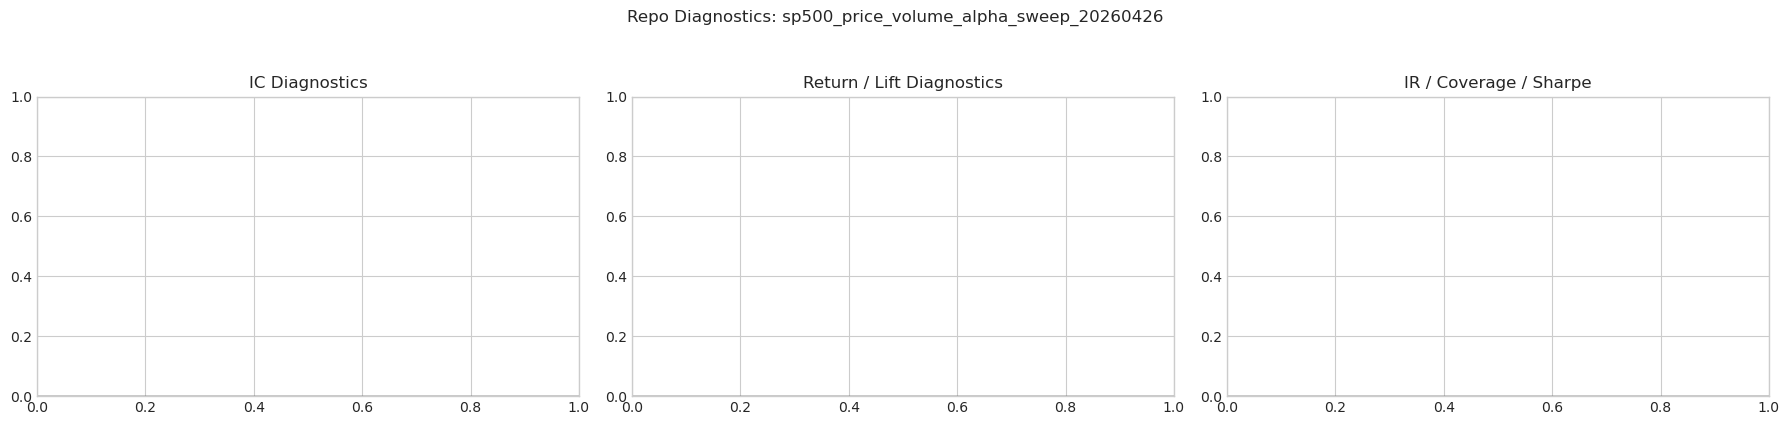

In [6]:
# Repo diagnostics plot (uses repo_summary.csv when available, else summary.csv)
diag = repo_summary if not repo_summary.empty else summary
if diag.empty:
    print('No repo summary-style diagnostics to plot')
else:
    x_col = None
    for c in ['horizon_rebalance_steps', 'horizon_days', 'horizon', 'period']:
        if c in diag.columns:
            x_col = c
            break
    x = diag[x_col].astype(str) if x_col else diag.index.astype(str)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for c in ['avg_rank_ic', 'ic_ir', 'ic_std']:
        if c in diag.columns:
            axes[0].plot(x, diag[c], marker='o', label=c)
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('IC Diagnostics')
    axes[0].legend(loc='best')

    for c in ['signal_mean_return', 'baseline_mean_return', 'lift_vs_baseline', 'lift_vs_base_rate']:
        if c in diag.columns:
            axes[1].plot(x, diag[c], marker='o', label=c)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Return / Lift Diagnostics')
    axes[1].legend(loc='best')

    for c in ['realized_active_ir', 'implied_ir', 'signal_coverage', 'sharpe']:
        if c in diag.columns:
            axes[2].plot(x, diag[c], marker='o', label=c)
    axes[2].axhline(0, color='black', linewidth=1)
    axes[2].set_title('IR / Coverage / Sharpe')
    axes[2].legend(loc='best')

    fig.suptitle(f'Repo Diagnostics: {selected}', y=1.05)
    fig.tight_layout()
    plt.show()

In [7]:
# Alphalens diagnostics plot
if alphalens_summary.empty and alphalens_turnover.empty:
    print('No Alphalens artifacts present for this run')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if not alphalens_summary.empty:
        p = alphalens_summary['period'].astype(str) if 'period' in alphalens_summary.columns else alphalens_summary.index.astype(str)
        if 'avg_rank_ic' in alphalens_summary.columns:
            axes[0].bar(p, alphalens_summary['avg_rank_ic'], alpha=0.8, label='avg_rank_ic')
        if 'ic_ir' in alphalens_summary.columns:
            axes[0].plot(p, alphalens_summary['ic_ir'], marker='o', color='black', label='ic_ir')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Alphalens IC Summary')
    axes[0].legend(loc='best')

    if not alphalens_turnover.empty:
        x = alphalens_turnover['period_days'] if 'period_days' in alphalens_turnover.columns else alphalens_turnover.index
        for c in ['avg_top_quantile_turnover', 'avg_bottom_quantile_turnover', 'avg_factor_rank_autocorrelation']:
            if c in alphalens_turnover.columns:
                axes[1].plot(x, alphalens_turnover[c], marker='o', label=c)
    axes[1].set_title('Alphalens Turnover / Stability')
    axes[1].legend(loc='best')

    fig.suptitle(f'Alphalens Diagnostics: {selected}', y=1.05)
    fig.tight_layout()
    plt.show()

No Alphalens artifacts present for this run


In [8]:
# Optional by-date time series view
d = repo_by_date if not repo_by_date.empty else by_date
if d.empty:
    print('No by-date diagnostics available')
else:
    d = d.copy().sort_values('date')
    h_col = 'horizon_days' if 'horizon_days' in d.columns else None

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    if h_col:
        for h, g in d.groupby(h_col):
            if 'active_return' in g.columns:
                axes[0].plot(g['date'], g['active_return'].cumsum(), label=f'h={h}')
            if 'ic' in g.columns:
                axes[1].plot(g['date'], g['ic'].rolling(12, min_periods=4).mean(), label=f'h={h}')
    else:
        if 'active_return' in d.columns:
            axes[0].plot(d['date'], d['active_return'].cumsum(), label='active_return')
        if 'ic' in d.columns:
            axes[1].plot(d['date'], d['ic'].rolling(12, min_periods=4).mean(), label='ic')

    axes[0].set_title('Cumulative Active Return')
    axes[1].set_title('Rolling IC Mean (window=12)')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[0].legend(loc='best')
    axes[1].legend(loc='best')
    fig.tight_layout()
    plt.show()

No by-date diagnostics available
